# <b>Kaggle Competition</b>

# <b>Objective</b>
##### Review the Chemical Process Monitoring Time-Series dataset provided on Kaggle [[Link]](https://www.kaggle.com/datasets/rohit8527kmr7518/chemical-process-monitoring-time-series-dataset/data).

# <b>Overview</b>

##### This dataset is synthetic and multivariate. It simulates a continuous system of chemical reactors operating in two regimes: `A` and `B`. Sensor inputs, control dynamics, seasonal effects, and fault development are recorded as a time series. Samples were collected over approximately 180 days at 1-minute intervals. Within each regime, several reactors operate in parallel. About 6% of recorded values are missing to simulate sensor dropouts. Information from the Kaggle dataset is provided below:

### <b>Regime A: Baseline Operation</b>
- Nominal Temperature/Pressure
- Efficient Cooling
- Lower Fault Probability
- Represents Stable Long-Term Operation

### <b>Regime B: Stress Operation</b>
- Higher Temperature/Pressure
- Reduced Cooling Efficiency
- Increased Sensor Noise
- Higher Fault Probability
- Represents Harsh/High-Throughput Conditions

### <b>Multi-Reactor Review</b>

For the reactors, the following rules apply:
- Same Process Logic
- Small Unit-Specific Differences

### <b>Data Dictionary</b>


| Category                   | Column Name             | Description                                           |
|----------------------------|------------------------|-------------------------------------------------------|
| Time & Identifiers          | timestamp              | Date and time when the sensor reading was recorded   |
|                             | operating_regime       | Operating condition (A = baseline, B = stressed)     |
|                             | reactor_id             | Unique identifier for each reactor unit              |
| Environmental               | ambient_temp_effect    | Slowly varying simulated ambient temperature influence|
| Core Sensors                | reactor_temp           | Internal reactor temperature                          |
|                             | reactor_pressure       | Internal reactor pressure                             |
|                             | feed_flow_rate         | Material inflow rate to the reactor                  |
|                             | coolant_flow_rate      | Cooling fluid flow rate                               |
|                             | agitator_speed_rpm     | Mixing speed of the agitator                          |
| Process Performance         | reaction_rate          | Speed of the chemical reaction                        |
|                             | conversion_rate        | Fraction of feed converted to product                |
|                             | selectivity            | Product purity or focus                               |
|                             | yield_pct              | Overall process yield percentage                      |
| Mechanical & Electrical     | vibration_rms          | Root-mean-square vibration level                     |
|                             | motor_current          | Electrical current drawn by the motor               |
|                             | power_consumption_kw   | Electrical power usage in kilowatts                 |
| Control Variables           | temp_setpoint          | Target temperature set by the control system        |
|                             | pressure_setpoint      | Target pressure set by the control system           |
| Targets                     | fault_type             | Fault class (0 = normal, 1–4 = fault types)         |
|                             |<b>efficiency_loss_pct</b>    | <b>Estimated percentage efficiency loss</b>                 |
|                             | time_to_fault_min      | Minutes remaining before fault onset                 |

#### <b>Note: For this assessment, the `efficiency_loss_pct` target variable was evaluated to highlight loss during production. Regime A was selected due to the reduced noise, increased cooling efficiency, and lower fault probability. EDA and feature engineering were conducted on Regime A's first reactor to serve as a blueprint for the others within the group.</b> 

# <b>Set Up</b>

### <b>Import Libraries</b>

In [1]:
# Import Libraries
import joblib
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
import shap 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Set Seed
seed_1 = 42

### <b> Kaggle Dataset Loading</b>

In [2]:
# Load Dataset
df_all = joblib.load("../data/dataset.joblib")

# <b>Exploratory Data Analysis (EDA)</b>

### <b>Review Columns</b>

In [3]:
# View Columns
df_all.columns

Index(['timestamp', 'operating_regime', 'reactor_id', 'ambient_temp_effect',
       'reactor_temp', 'reactor_pressure', 'feed_flow_rate',
       'coolant_flow_rate', 'agitator_speed_rpm', 'reaction_rate',
       'conversion_rate', 'selectivity', 'yield_pct', 'vibration_rms',
       'motor_current', 'power_consumption_kw', 'temp_setpoint',
       'pressure_setpoint', 'fault_type', 'efficiency_loss_pct',
       'time_to_fault_min'],
      dtype='object')

#### <b>Note: There are redundancies within the dataset especially with the setpoint columns. For simplicity and clarity in this analysis, the reactor’s performance will be evaluated without including the setpoints. However, for future work, both the setpoint values and their deviation from actual readings can be further examined to assess their potential impact on system performance.</b>

### <b>Review Head</b>

In [4]:
# Explore Head
df_all.head()

,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
0,2024-01-01 00:00:00,A,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,0.724542,...,91.927424,82.032893,1.470297,45.882315,41.294083,180.0,12.0,0,0.0,NaN
1,2024-01-01 00:01:00,A,A_R1,0.000485,182.249820,15.706975,98.932369,NaN,302.283603,0.728999,...,91.581466,81.301503,1.425847,46.755905,42.080314,180.0,12.0,0,0.0,NaN
2,2024-01-01 00:02:00,A,A_R1,0.000970,183.129737,15.593397,99.792219,80.593736,305.814440,0.732519,...,91.895056,82.006626,1.448190,NaN,NaN,NaN,12.0,0,NaN,NaN
3,2024-01-01 00:03:00,A,A_R1,0.001454,183.020987,15.527333,99.854222,80.190444,304.436123,0.732084,...,91.544885,81.562261,1.473448,45.862171,41.275954,180.0,12.0,0,0.0,NaN
4,2024-01-01 00:04:00,A,A_R1,0.001939,183.077096,NaN,99.302349,78.571707,304.811418,0.732308,...,92.258005,82.411124,1.523491,46.880227,42.192204,180.0,12.0,0,NaN,NaN


### <b>Review Tail</b>

In [5]:
# Explore Tail
df_all.tail()

,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
777595,2024-03-30 23:55:00,B,B_R3,NaN,196.730269,17.262377,108.591129,71.495234,313.065505,0.786921,...,91.740047,82.318829,1.445766,NaN,42.084467,192.0,13.5,0,0.0,NaN
777596,2024-03-30 23:56:00,B,B_R3,-1.454452e-03,195.362650,17.379930,107.344266,73.425892,308.499462,0.781451,...,91.802270,82.101385,1.418151,45.818965,41.237069,192.0,13.5,0,0.0,NaN
777597,2024-03-30 23:57:00,B,B_R3,-9.696348e-04,196.316381,17.459625,109.488985,72.066655,292.328953,0.785266,...,91.683646,82.357529,1.510955,46.471420,41.824278,192.0,13.5,0,0.0,NaN
777598,2024-03-30 23:58:00,B,B_R3,-4.848174e-04,194.926889,17.423614,109.004906,70.863233,298.096724,NaN,...,91.717088,82.395115,1.335763,45.893437,41.304093,192.0,13.5,0,0.0,NaN
777599,2024-03-30 23:59:00,B,B_R3,-2.449294e-15,195.261836,17.297994,108.044145,72.796681,NaN,0.781047,...,91.547481,82.346868,1.508003,46.291404,41.662263,192.0,13.5,0,0.0,NaN


#### <b>Note: The dataset is organized by time spanning two months ascending from 2024-01-01 00:00:00 to 2024-03-30 23:59:00. `timestamp` is formatted in ISO 8601 variation. For easier analysis and visualization, a `time_elapsed` column will be created to measure time passed since the start.</b> 

### <b>Review Reactor Information</b>

In [6]:
# Get Names of Reactors
reactor_names = sorted(df_all["reactor_id"].unique().tolist())
reactor_names_A = [name for name in reactor_names if name.startswith('A_')]
operating_regime = sorted(df_all["operating_regime"].unique().tolist())

# See Reactor Information
print("Operating Regime:", operating_regime)
print("Reactor Names:", reactor_names)
print("Reactor Names, A:", reactor_names_A)
print("Reactor Count:", len(reactor_names))

Operating Regime: ['A', 'B']
Reactor Names: ['A_R1', 'A_R2', 'A_R3', 'B_R1', 'B_R2', 'B_R3']
Reactor Names, A: ['A_R1', 'A_R2', 'A_R3']
Reactor Count: 6


#### <b>Note: `A_R1` is chosen as the template for EDA and feature engineering. Thus, the `operating_regime` column is not necessary.</b> 

### <b>Select for Regime A Reactors</b>

In [7]:
# Create List of Columns to Remove
col_sp = ['operating_regime', 'temp_setpoint', 'pressure_setpoint']

# Select Regime A's Values Only
df_A = df_all[df_all['operating_regime'] == 'A'].copy()

# Remove Columns
df_A = df_A.drop(columns=col_sp)

# Confirm Columns Removed
print([col not in df_A.columns for col in col_sp])

[True, True, True]


### <b>Review Statistics</b>

In [8]:
# Show Statistics with 2 Decimals
df_A.describe().round(2)

,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,conversion_rate,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,fault_type,efficiency_loss_pct,time_to_fault_min
count,365600.00,365285.00,365396.00,365354.00,365436.00,365316.00,365284.00,365656.00,365085.00,365529.00,365677.00,365472.00,365626.00,388800.00,365344.00,13223.00
mean,-0.00,181.30,15.68,99.90,79.95,299.99,0.73,99.01,91.69,81.74,1.51,46.03,41.40,0.09,0.54,514.23
std,7.07,1.14,0.11,1.52,1.82,5.01,0.00,0.65,0.20,0.31,0.14,0.60,0.46,0.52,3.00,339.57
min,-10.00,177.79,15.21,77.48,66.59,277.87,0.71,88.57,90.64,80.40,1.28,43.71,39.23,0.00,0.00,0.00
25%,-7.07,180.42,15.61,99.30,78.63,296.62,0.72,98.85,91.55,81.54,1.47,45.66,41.09,0.00,0.00,233.00
50%,-0.00,181.11,15.68,99.99,79.96,299.98,0.72,99.06,91.69,81.74,1.50,46.01,41.40,0.00,0.00,469.00
75%,7.07,182.22,15.75,100.67,81.31,303.37,0.73,99.27,91.82,81.95,1.54,46.36,41.71,0.00,0.00,758.00
max,10.00,189.13,16.20,104.61,86.26,328.09,0.74,100.44,92.54,83.14,3.62,52.29,43.53,4.00,25.00,1416.00


#### <b>Note: `vibration_rms` potentially suffers from large spikes. The mean is `1.51`, while the max is `3.62`, which indicates possible jumps in vibration or mechanical issues.</b>

#### <b>`time_to_fault_min` has a wide range, with a median of `469.00` and a standard deviation of `339.57`. This indicates high variance in time between faults. For `efficiency_loss_pct`, the mean is `0.54`% and the max is `25.00`%, which shows that rare efficiency losses can be severe.</b>

#### <b>Finally, for `reactor_pressure` and `reactor_temp`, the standard deviations are `7.07` and `1.14`, respectively, with `15.21` to `16.20` and `177.79` to `189.13` as the lower and upper bounds. This narrow range indicates stability.</b> 

### <b>Review Columns Size, Missing Info, and DataTypes</b>

In [9]:
# Get Total Length
total_rows = len(df_A)

# Get DataType, Filled Data, Missing Count, and Missing Percentage
info = pd.DataFrame({
    'DType': df_A.dtypes.astype(str),
    'Non_Null': df_A.notna().sum(),
    'Missing_Count': df_A.isna().sum(),
    'Missing_Perc': (df_A.isna().sum() / total_rows * 100).round(2)
})

# Display Info
info['Missing_Perc'] = info['Missing_Perc'].astype(str) + '%'
display(info)

,DType,Non_Null,Missing_Count,Missing_Perc
timestamp,object,388800,0,0.0%
reactor_id,object,388800,0,0.0%
ambient_temp_effect,float64,365600,23200,5.97%
reactor_temp,float64,365285,23515,6.05%
reactor_pressure,float64,365396,23404,6.02%
feed_flow_rate,float64,365354,23446,6.03%
coolant_flow_rate,float64,365436,23364,6.01%
agitator_speed_rpm,float64,365316,23484,6.04%
reaction_rate,float64,365284,23516,6.05%
conversion_rate,float64,365656,23144,5.95%


#### <b>Note: `NaN` values are present across several columns, with a particularly large amount in `time_to_fault_min`. It must be determined whether these values are random or clustered to decide how to address them.</b> 

#### <b>All `timestamp`, `reactor_id`, and `fault_type` values are accounted for. Most remaining columns have approximately `~6%` missing values due to simulated sensor noise. `time_to_fault_min` has the highest missingness at `96.62%`, indicating that these values are sparsely populated.</b> 

#### <b>Data types include floats, integers, and objects. All data except the categorical variables and timestamps is `float64`. This simplifies operations within and across columns because no additional type conversion is required.</b> 

### <b>Visualize Missing Information</b>

<Axes: >

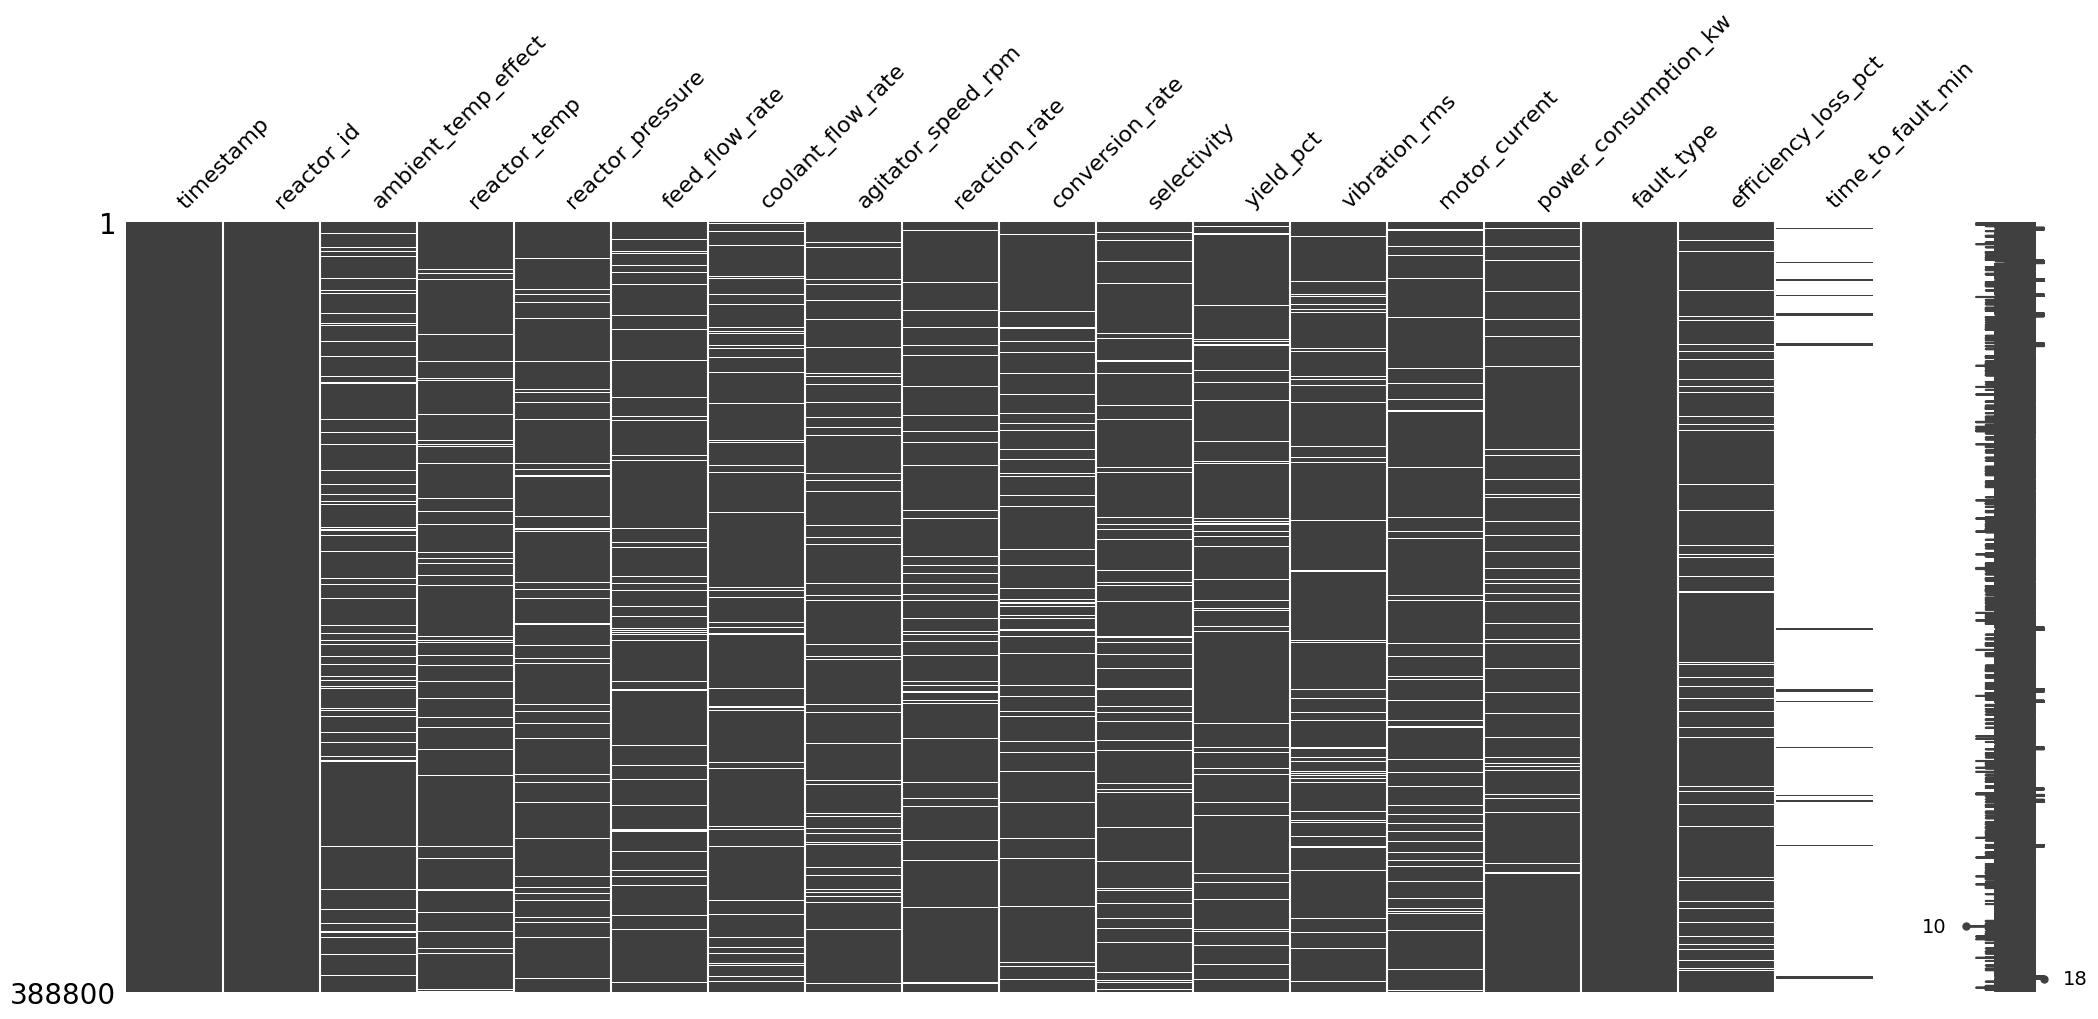

In [10]:
# Visualize the Missing Values
msno.matrix(df_A)

#### <b>Note: No clear correlation is observed between missingness in one column and missingness in others.</b>

#### <b>The sparseness of `time_to_fault_min` shows that values are distributed across time, with thicker bars indicating clustered recordings near fault events. This variable is not being evaluated here: only `3.3%` of data is available, and imputing it would create stepwise decay behavior that differs from the other continuous physical variables.</b>

#### <b>Although correlations could be computed, the data is too sparse and may mislead the model. Therefore, this column and the associated `fault_type` column will be removed. The remaining `~6%` missing values are sparsely distributed in sensor columns, supporting linear interpolation for imputation.</b> 

In [11]:
# Create List of Columns to Remove
col_fal = ['time_to_fault_min', 'fault_type']

# Remove 'operating_regime' Column (Unnecessary)
df_A = df_A.drop(columns=col_fal)

# Confirm Columns Removed
print([col not in df_A.columns for col in col_fal])

[True, True]


### <b>Helper Function for Plotting</b>

Below is a helper function for plotting the following graphs. It places all plots into a grid.

In [12]:
# Unified Grid Plotting Function
def unified_grid(data, columns, grid_type=2,
                 x_col=None, n_cols=3, 
                 figsize=(5,3)):     
    

    # Define the Rows, Axes
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0]*n_cols, figsize[1]*n_rows))
    axes = axes.flatten()    # For NumPy Axis Labeling

    # Loop Through and Depending on Argument Generate the Following Graph
    for row, col in enumerate(columns):
        
        # Create Scatter Plots
        if grid_type == 0:
            axes[row].scatter(data[x_col], data[col], label=col, s=5)
            axes[row].set_ylabel(col)
            axes[row].legend(loc='upper right')
            axes[row].tick_params(axis='x', rotation=30)

        # Create Box Plots
        elif grid_type == 1:
            axes[row].boxplot(data[col].dropna(), 
                              vert=True)
            axes[row].set_title(col)
            axes[row].set_xticks([])  
            axes[row].set_xticklabels([])

        # Create Histograms
        elif grid_type == 2:
            sns.histplot(data[col], kde=True, ax=axes[row])     # Ensure KDE Curve onto Histograms
            axes[row].set_title(f'Distribution of {col}')


    # Turn off Empty Grids
    for ax in axes[len(columns):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### <b>Scatter Plots</b>

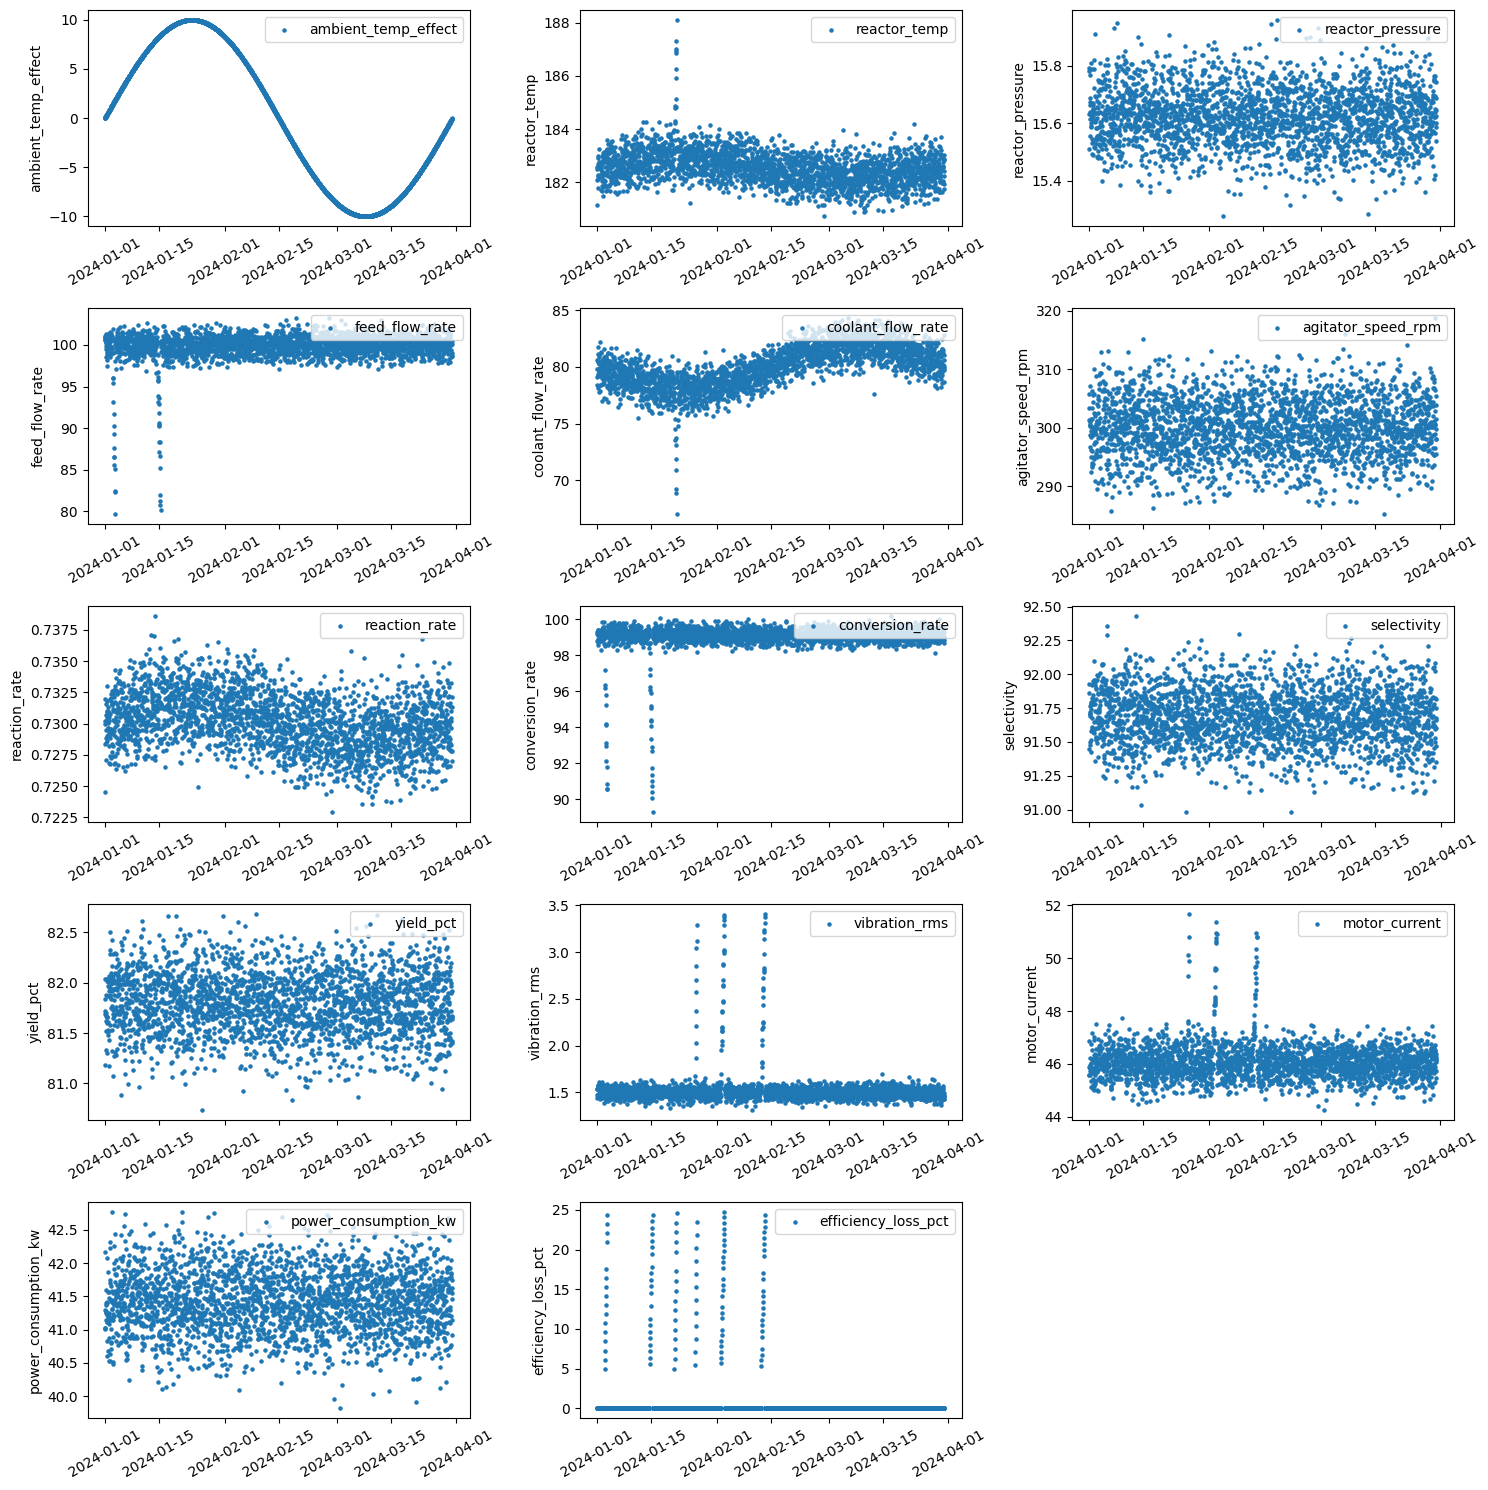

In [13]:
# Downsample for Plotting
step = 50
reactor_id = 'A_R1'

# Define Time-Based and Categorical Column to Remove
plt_omit = ['timestamp', 'reactor_id']

# Remove Categorical and Timestamp Columns
params = [col for col in df_A.columns 
          if col not in 
          plt_omit]


df_reactor = df_A[df_A['reactor_id'] == reactor_id].copy()
df_downsampled = df_reactor.iloc[::step].copy()

# Convert timestamp to datetime for better formatting
if 'timestamp' in df_downsampled.columns:
    df_downsampled.loc[:, 'timestamp'] = pd.to_datetime(df_downsampled['timestamp'])

# Use unified_grid for scatter plots
unified_grid(df_downsampled, params, grid_type=0, x_col='timestamp', n_cols=3, figsize=(5,3))

#### <b>Note: `ambient_temp_effect` displays a sinusoidal pattern as does `reaction_rate`, `reactor_temp`, and `coolant_flow_rate`. This is consistent with the expectation that cyclical changes in ambient temperature would drive corresponding fluctuations. The other sensors remain relatively stable and show plateau-like behavior with some stochastic variation. Occasional abrupt jumps may indicate potential sudden failures.</b>

### <b>Boxplots</b>

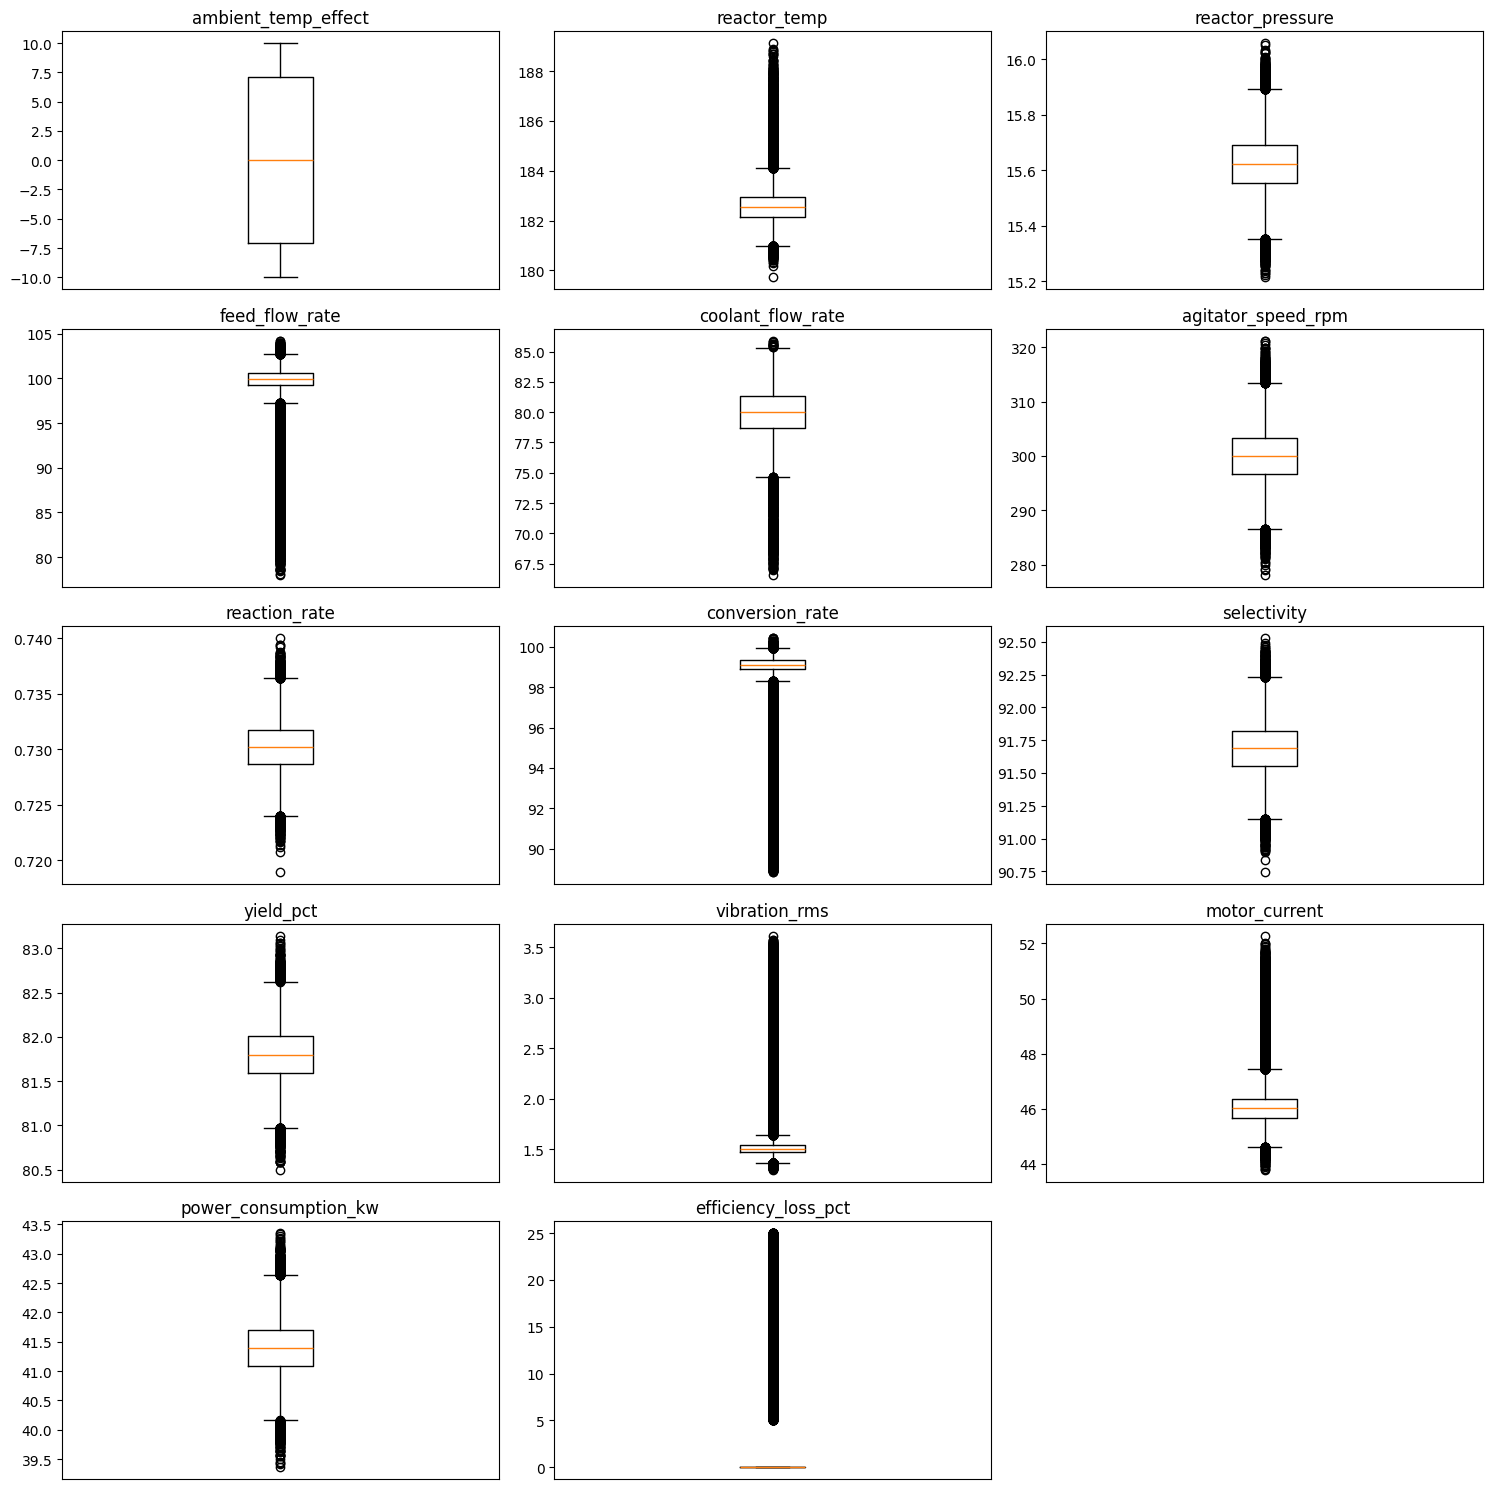

In [14]:
# Plot
unified_grid(df_reactor, params, grid_type=1, n_cols=3, figsize=(5,3))

#### <b>Note: `ambient_temp_effect` again mirrors a predictable pattern shown in the scatter plot with a reliably distributed boxplot. There are few outliers, which implies that this parameter, although oscillating, is predictably doing so, which points to machine health in this regard.</b> 

#### <b>The rest of the sensors have thin boxplots with several outliers that surpass the minimum and maximum values frequently. For `reactor_temp`, `efficiency_loss_pct`, `motor_current`, and `vibration_rms`, the outliers are skewed above the maximums, whereas for `feed_flow_rate`, `coolant_flow_rate`, and `conversion_rate`, the opposite trend is observed. This potentially indicates positive or negative correlations that will be investigated with a heatmap.</b>

### <b>Sample of Distribution Plots</b>

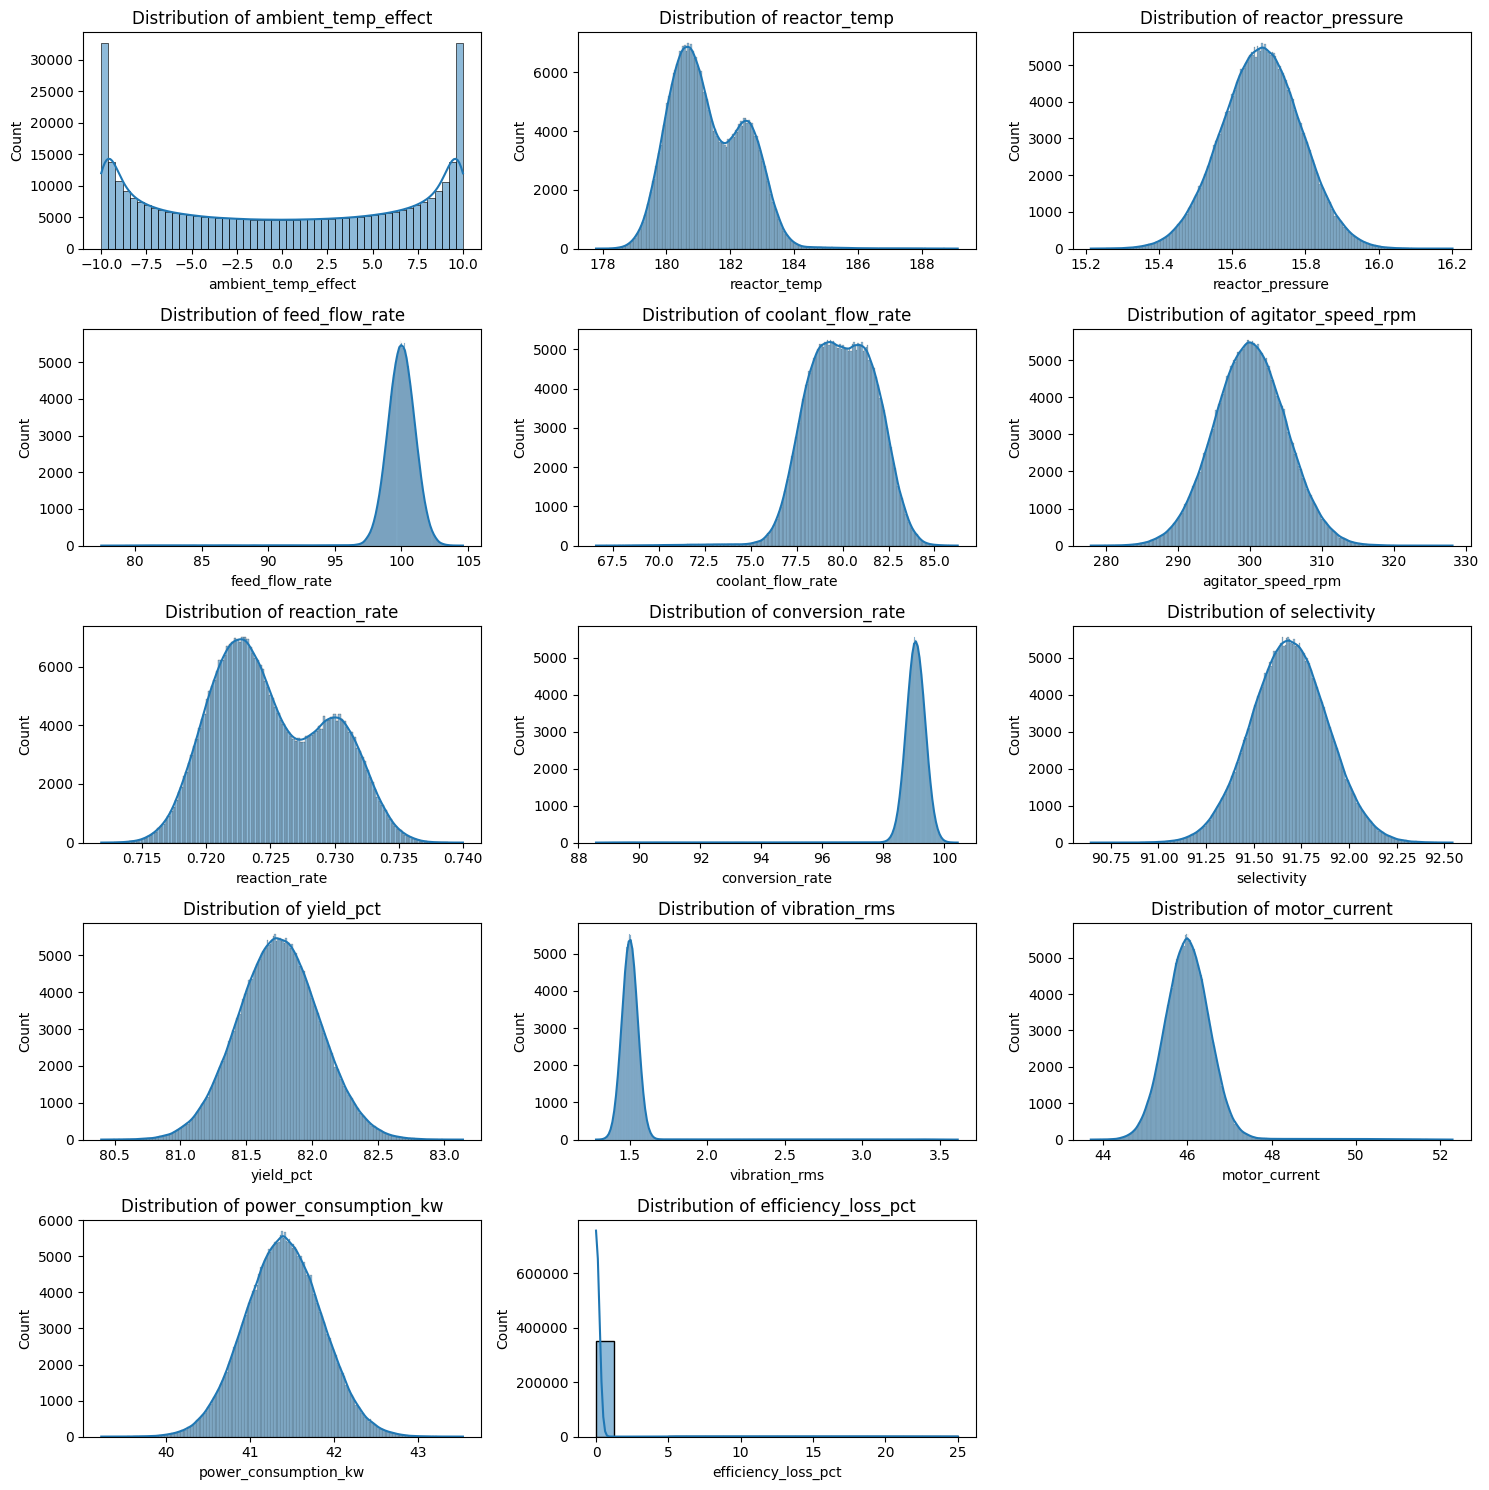

In [15]:
# EDA: Distribution plots for numeric columns in a grid
unified_grid(df_A, params, grid_type=2, n_cols=3, figsize=(5,3))

#### <b>Note: Reaction rate, temperature, and flow rate variables show multimodal distributions which may indicate nonlinear relationships or multiple operating regimes. Tree-based models can capture nonlinear interactions and are robust to outliers (as observed in the boxplots) and multimodal feature distributions. Thus, a tree-based modeling approach will be used.</b>

### <b>Heatmap</b>

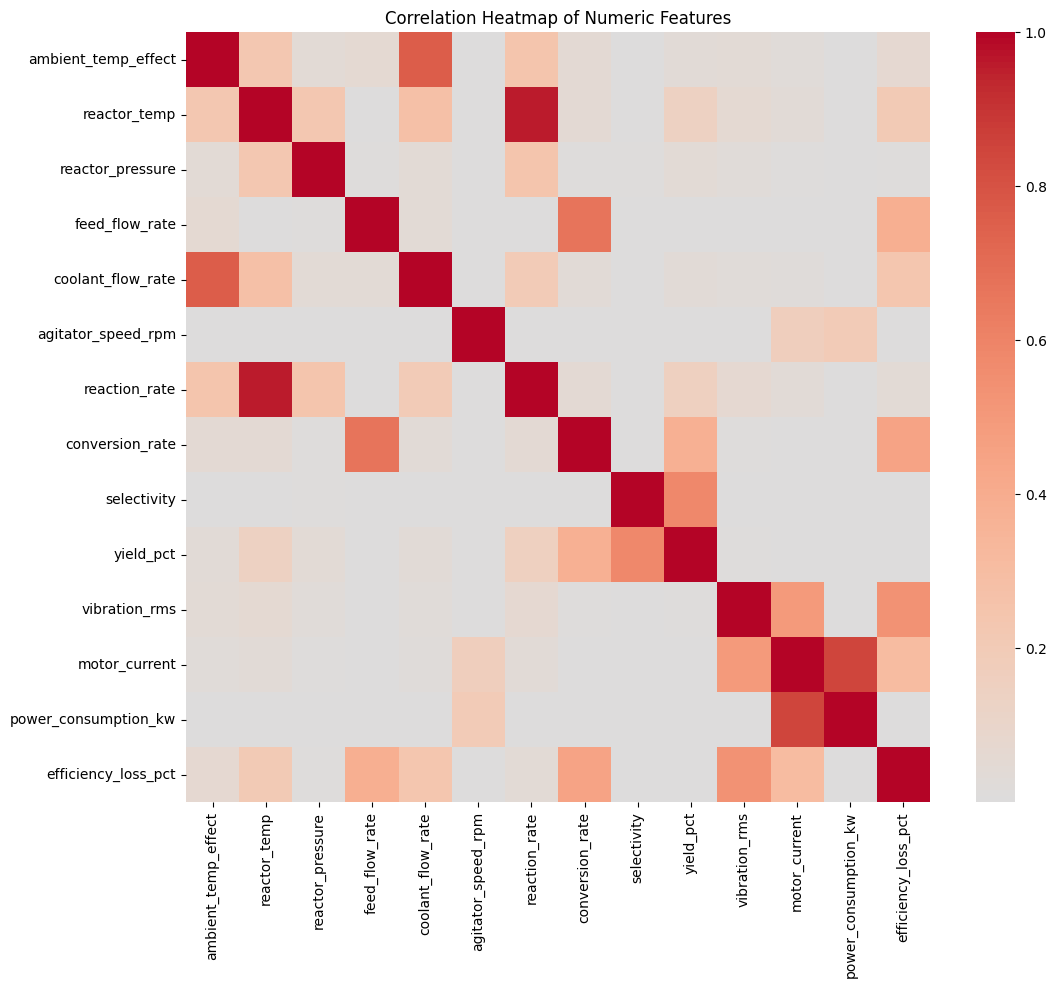

In [16]:
# Get Numerical Columns
numeric_cols = [col for col in df_A.columns if col not in plt_omit]

# Create Correlation Matrix
corr = df_A[numeric_cols].corr().abs()
upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Plot Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

#### <b>Note: The heatmap shows strong correlations between the columns that are consistent with physical principles. Some include `reactor_temp` and `reaction_rate` (as expected through the `Arrhenius Equation`), `vibration_rms` and `efficiency_loss_pct` (`energy conservation`), `motor_current` and `power_consumption_kw` (as expected through `Ohm's Law`), as well as `conversion_rate` with `feed_flow_rate` (`mass balance`). The correlation matrix will be further evaluated numerically. Features will be removed if the correlation is above `0.95` to reduce redundancy. </b> 

# <b>Preprocessing</b>

### <b>Interpolate Missing Values</b>

In [17]:
# Apply Interpolation 

# Remove Unneeded Columns for Interpolation
int_omit = ['timestamp', 'reactor_id']
cols_omit = [col for col in df_A.columns if col not in int_omit]

# Apply Interpolation
for col in cols_omit:
    df_A[col] = df_A[col].interpolate(method='linear')

#### <b>Note: Since this dataset comes from a physical and continuous system, missing values can be imputed using linear interpolation along the time axis to preserve the natural trend.</b>

### <b>Interpolation Confirmation</b>

In [18]:
# Confirm Columns Have Been Filled
missing_summary = df_A.isna().sum()

# Show
print("Missing Values:")
print(missing_summary)

Missing Values:
timestamp               0
reactor_id              0
ambient_temp_effect     0
reactor_temp            0
reactor_pressure        0
feed_flow_rate          0
coolant_flow_rate       0
agitator_speed_rpm      0
reaction_rate           0
conversion_rate         0
selectivity             0
yield_pct               0
vibration_rms           0
motor_current           0
power_consumption_kw    0
efficiency_loss_pct     0
dtype: int64


# <b>Feature Engineering</b>

### <b>Time-based Features (Elapsed Time)</b>

Create a `time_elapsed` column from `timestamp`. This represents elapsed time since the start in a numeric format that the tree model can ingest. The `timestamp` column will be removed afterward because it is no longer needed.

In [19]:
# Convert Timestamp to Time Elapsed Column
df_A['timestamp'] = pd.to_datetime(df_A['timestamp'])
start_time = df_A['timestamp'].min()
df_A['time_elapsed'] = ((df_A['timestamp'] - start_time).dt.total_seconds())    # Gives Column in float

# Sort by Time Elapsed
df_A = df_A.sort_values('time_elapsed').reset_index(drop=True)

# Remove Timestamp Column
df_A = df_A.drop(columns=["timestamp"])

In [20]:
# Confirm Time Elapsed Column
df_A['time_elapsed'].head(6)

0     0.0
1     0.0
2     0.0
3    60.0
4    60.0
5    60.0
Name: time_elapsed, dtype: float64

### <b>Selecting for Lag and Window</b>

This is a time-series model, so lag features and rolling statistics are needed for the tree to capture temporal relationships. Here, the amount of lag is evaluated to determine whether adding more lag features yields meaningful improvement or diminishing returns.

In [21]:
# Create df for Lag based on Regime A's df 
df_lag = df_A[df_A['reactor_id'] == 'A_R1'].copy()

# Set Up Foundation for New Lag Table
col_corr = ['efficiency_loss_pct']
corr_matrix = pd.DataFrame()

# Check Lag Features
for lag in range(1, 10):      

    # Shift and Obtain Result for Lag Column
    col_name = f'lag_{lag}'
    df_lag[col_name] = df_lag['efficiency_loss_pct'].shift(lag)
    
    # Calculate Correlation for Lag
    corr_value = df_lag['efficiency_loss_pct'].corr(df_lag[col_name])
    
    # Append to Lag Column Table
    col_corr.append(col_name)

# Get Correlation Matrix for Lags
corr_matrix = df_lag[col_corr].corr()
print(corr_matrix['efficiency_loss_pct'])

efficiency_loss_pct    1.000000
lag_1                  0.998760
lag_2                  0.997512
lag_3                  0.996263
lag_4                  0.995015
lag_5                  0.993767
lag_6                  0.992519
lag_7                  0.991271
lag_8                  0.990023
lag_9                  0.988774
Name: efficiency_loss_pct, dtype: float64


#### <b>Note: Lower lag numbers are more highly correlated with the target. There are diminishing returns after lag 4. Adding more lag columns increases computation cost and can introduce noise or overfitting. More than one lag variable is needed for rolling standard deviation, so lags 1-3 are selected.</b>

### <b>Lag Features and Rolling Statistics</b>

In [22]:
# Define Lags and Window Size for Rolling Statistics
useful_lags = [1, 2, 3]
window_size = 3

# Create New df for Stats and Dictionary for New Columns
df_stat = df_A.copy()
col_stat = {}

# For Each Column, Except non-float Dtypes, Get Rolling Statistics and Lag Features
for col in df_A.columns:
    if col not in ['timestamp', 'reactor_id']:        

        #  Calculate Rolling Statistics, min_periods = 1 Ensures Mean isn't NA and .shift(1) Gets Past Information
        col_stat[f'{col}_roll_mean'] = df_A[col].rolling(window=window_size, min_periods=1).mean().shift(1)
        col_stat[f'{col}_roll_std']  = df_A[col].rolling(window=window_size, min_periods=1).std().shift(1)

        #  Get Lag Features
        for lag in useful_lags:
            col_stat[f'{col}_lag{lag}'] = df_A[col].shift(lag)

# Convert to DataFrame
df_stat_new = pd.DataFrame(col_stat)
df_stat = pd.concat([df_stat, df_stat_new], axis=1)

### <b>Interaction features</b>

This step evaluates whether combining relationships between features can improve model performance.

In [23]:
# Set Standard Correlation Thresholds
thres_low = 0.3
thres_high = 0.95

# Get Numerical Columns
numeric_cols = [col for col in df_A.columns if col not in plt_omit]

# Create Correlation Matrix
corr = df_A[numeric_cols].corr().abs()
upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Set Up Dictionary for Key:Value Pairs
corr_pairs = {}

# Iterate Through Upper Triangle, Ignore Target Column
for col1 in [col for col in upper_triangle.columns if col != 'efficiency_loss_pct']:
    for col2 in [col for col in upper_triangle.index if col != 'efficiency_loss_pct']:

        # Sort by Column Names to Ensure Uniqueness
        key = tuple(sorted([col1, col2]))

        # If Not Evaluated Yet
        if key not in corr_pairs:

            # Assign Value
            val = upper_triangle.loc[col2, col1]

            # If Meets Threshold, Evaluate
            if thres_low <= val <= thres_high:
                corr_pairs[key] = val

# Sort Correlation Pairs
sorted_data = dict(sorted(corr_pairs.items(), key=lambda item: item[1]))

# Save into DataFrame
df_corr = pd.DataFrame(sorted_data.items(), columns=['Feature Pair', 'Correlation'])
df_corr = df_corr.sort_values(by='Correlation', ascending=False).head(10)

# Check the correlation result
print(df_corr)

                               Feature Pair  Correlation
8             (reaction_rate, reactor_temp)     0.943466
7       (ambient_temp_effect, time_elapsed)     0.779688
6  (ambient_temp_effect, coolant_flow_rate)     0.769116
5     (motor_current, power_consumption_kw)     0.768592
4         (conversion_rate, feed_flow_rate)     0.672789
3         (coolant_flow_rate, time_elapsed)     0.589563
2                  (selectivity, yield_pct)     0.527716
1            (motor_current, vibration_rms)     0.505118
0              (conversion_rate, yield_pct)     0.343819


#### <b>Note: Investigating whether to remove one feature from the pair `('reaction_rate', 'reactor_temp')`, since the correlation value (`0.94`) is close to the `0.95` threshold, as expected from the `Arrhenius Equation`.</b> 

#### <b>`('motor_current', 'power_consumption_kw')` are physically related and therefore redundant as separate feature columns, as expected from `Ohm's Law`.</b>

### <b>Remove Power-Current Feature Column</b>

In [24]:
# Delete Unneeded Feature Column
del corr_pairs[tuple(sorted(['motor_current', 'power_consumption_kw']))]

### <b>Explore Reactor-Target Correlations</b>

In [25]:
# Review 1st Column's Impact on Target
value = upper_triangle.loc["reaction_rate", "efficiency_loss_pct"]
print("Reaction Rate x Efficiency Loss:", value)

# Review 2nd Column's Impact on Target
value = upper_triangle.loc["reactor_temp", "efficiency_loss_pct"]
print("Reactor Temp x Efficiency Loss: ", value)

Reaction Rate x Efficiency Loss: 0.04691097492962186
Reactor Temp x Efficiency Loss:  0.20977485609639637


#### <b>Note: The `reaction_rate` column has less influence on `efficiency_loss_pct`. Therefore, it will be removed instead of `reactor_temp`. The interaction feature for `('reaction_rate', 'reactor_temp')` will also be removed due to its high correlation, which would introduce redundancy in the tree model.</b>

In [26]:
# Remove Reaction Rate (Feature) Column
del corr_pairs[tuple(sorted(['reaction_rate', 'reactor_temp']))]
df_A = df_A.drop(columns=["reaction_rate"])

# Remove from Statistics DataFrame
cols_rmv = [col for col in df_stat.columns if 'reaction_rate' in col]
df_stat = df_stat.drop(columns = cols_rmv)

### <b> Save to DataFrame </b>

In [27]:
# Prepare DataFrame
df_fe = df_A.copy()

# Compute the Feature Columns for Appropriate Correlation Pairs
for (col1, col2), corr_val in corr_pairs.items():
   
    # Create Interaction Feature
    df_fe[f"{col1}_x_{col2}"] = df_A[col1] * df_A[col2]

# View Feature Engineering DataFrame
df_fe.head()

,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,conversion_rate,selectivity,yield_pct,...,power_consumption_kw,efficiency_loss_pct,time_elapsed,ambient_temp_effect_x_coolant_flow_rate,conversion_rate_x_feed_flow_rate,conversion_rate_x_yield_pct,selectivity_x_yield_pct,motor_current_x_vibration_rms,ambient_temp_effect_x_time_elapsed,coolant_flow_rate_x_time_elapsed
0,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,99.151760,91.927424,82.032893,...,41.294083,0.0,0.0,0.000000,10025.123648,8133.705733,7541.072493,67.460642,0.000000,0.000000
1,A_R3,0.000242,179.850553,15.884923,99.608202,79.846183,299.316544,98.792799,91.827103,81.646709,...,40.921128,0.0,0.0,0.019355,9840.573164,8066.106968,7497.380780,67.647863,0.000000,0.000000
2,A_R2,0.000000,181.174608,15.747025,101.510668,78.450699,299.196888,98.986188,91.801170,81.783431,...,40.370144,0.0,0.0,0.000000,10048.154096,8095.430031,7507.814609,66.361254,0.000000,0.000000
3,A_R1,0.000485,182.249820,15.706975,98.932369,79.874191,302.283603,98.638957,91.581466,81.301503,...,42.080314,0.0,60.0,0.038724,9758.585683,8019.495504,7445.710890,66.666770,0.029089,4792.451430
4,A_R3,0.000485,180.236922,15.738926,100.307067,79.215299,296.580743,98.628310,91.612934,81.615648,...,41.796460,0.0,60.0,0.038405,9893.116551,8049.613466,7477.049008,68.796656,0.029089,4752.917948


### <b>Combine Feature Engineering, Stats, and Regime A's DataFrame</b>

In [28]:
# Assure All are Descending By reactor_id and time_elapsed
sort_cols = ["time_elapsed", "reactor_id"]
df_A = df_A.sort_values(sort_cols, ascending=[True, True]).reset_index(drop=True)
df_stat = df_stat.sort_values(sort_cols, ascending=[True, True]).reset_index(drop=True)
df_fe = df_fe.sort_values(sort_cols, ascending=[True, True]).reset_index(drop=True)

# Combine All Columns Together
df_combined = df_A.copy()
for df in [df_stat, df_fe]:
    for col in df.columns:
        df_combined[col] = df[col]

# Drop Rows with Lag or Rolling Stats NaN Values
df_combined = df_combined.dropna().reset_index(drop=True)

### <b>Confirm that Column Count Matches</b>

In [29]:
# Print Column Sizes
names = ["df_A", "df_stat", "df_fe", "df_combined"]
lengths = [len(df_A.columns), len(df_stat.columns), len(df_fe.columns), len(df_combined.columns)]

pd.DataFrame(zip(names, lengths), columns=["Column", "Lengths"])

,Column,Lengths
0,df_A,15
1,df_stat,85
2,df_fe,22
3,df_combined,92


#### <b>Note: The original DataFrame has `15` columns. The Lag DataFrame adds `70` unique columns (`85` − `15`), and the feature engineering DataFrame adds `7` unique columns (`22` − `15`). Combined, this gives a total of `92` columns, which matches the sum of `15`, `70`, and `7`.</b>

### <b>Review New DataFrame</b>

In [30]:
# Review
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388797 entries, 0 to 388796
Data columns (total 92 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   reactor_id                               388797 non-null  object 
 1   ambient_temp_effect                      388797 non-null  float64
 2   reactor_temp                             388797 non-null  float64
 3   reactor_pressure                         388797 non-null  float64
 4   feed_flow_rate                           388797 non-null  float64
 5   coolant_flow_rate                        388797 non-null  float64
 6   agitator_speed_rpm                       388797 non-null  float64
 7   conversion_rate                          388797 non-null  float64
 8   selectivity                              388797 non-null  float64
 9   yield_pct                                388797 non-null  float64
 10  vibration_rms                   

# <b>Model (Baseline and Separation)</b>

### <b>Baseline</b>

#### <b>Note: This model serves as a baseline template.</b>

<b>The tree parameters were constrained due to both fit and performance considerations. The following values were selected and can be fine-tuned in future work:</b>
| Parameter            | Value        | Reasoning |
|---------------------|-------------|-------------|
| max_depth           | 5         | Typical heuristic range is 10–15; significant overfitting was observed, so it was adjusted to 5 in practice |
| min_samples_leaf    | 5           | Reduced from 10 to limit overfitting |
| min_samples_split   | 15          | Reduced from higher values to improve performance |
| n_estimators        | 50         | Reduced from 100 due to performance bottlenecks |
| max_features        | 0.3      | Increased from 0.1 to allow more tree complexity, since `n_estimators` was performance-limited |
| max_samples         | 0.25        | Heuristic choice to increase tree diversity |
| n_jobs              | -1          | Uses all CPU cores for faster training |
| random_state        | seed_1      | Ensures reproducibility |
| oob_score           | True        | Enables out-of-bag validation |

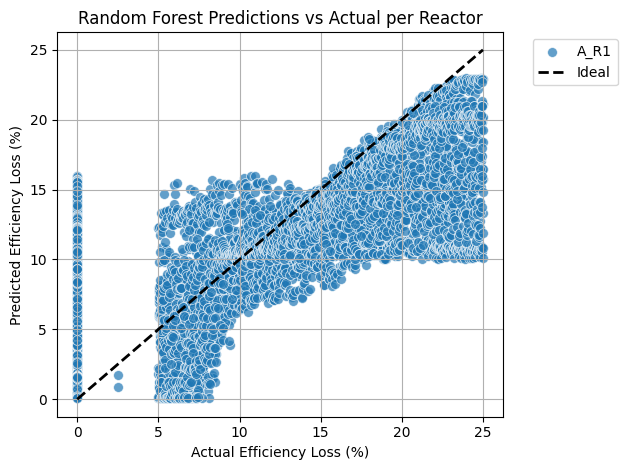

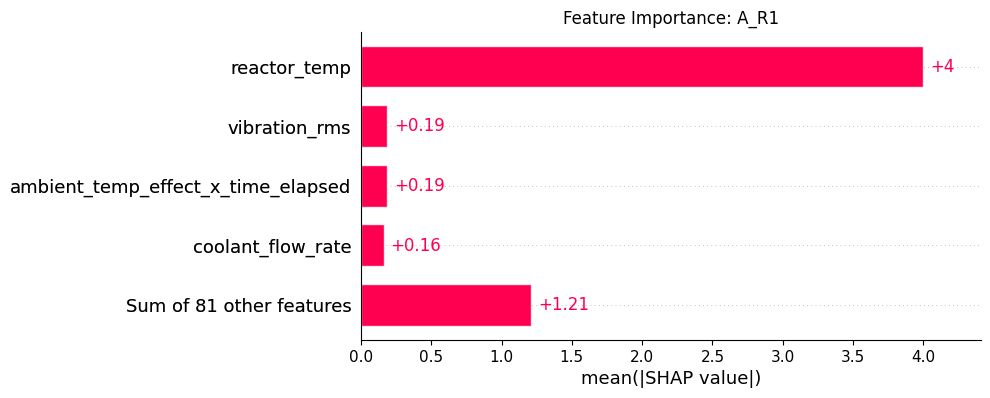

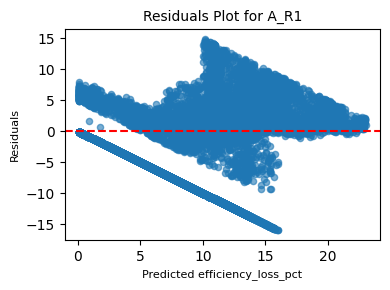

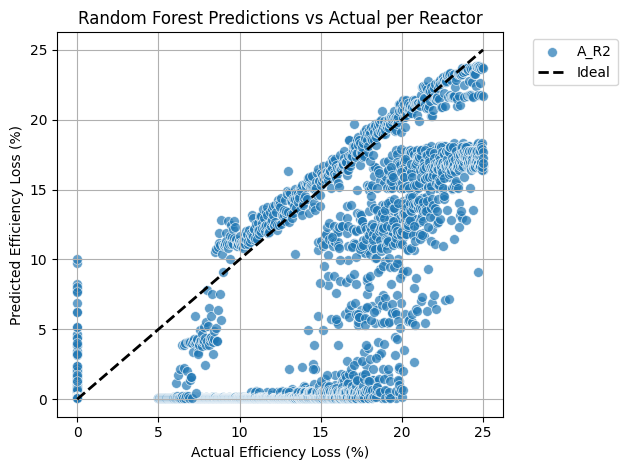

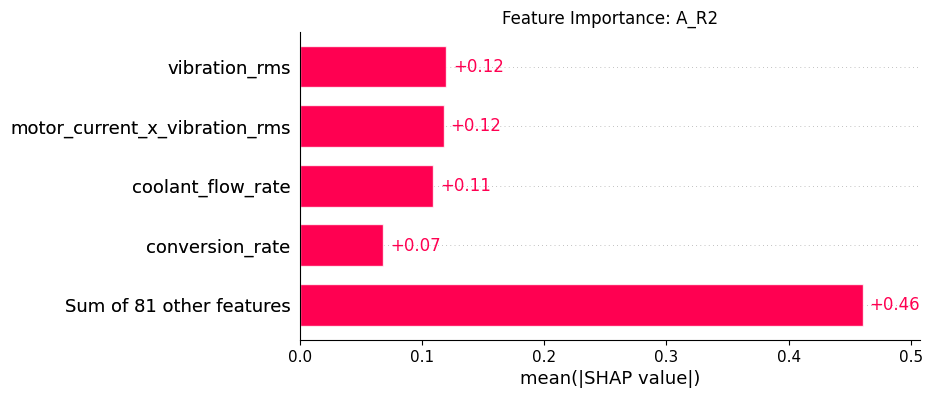

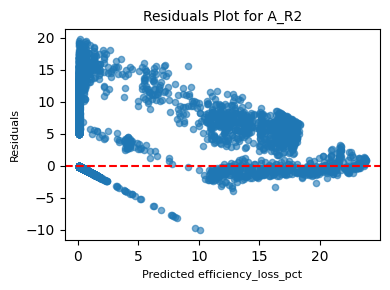

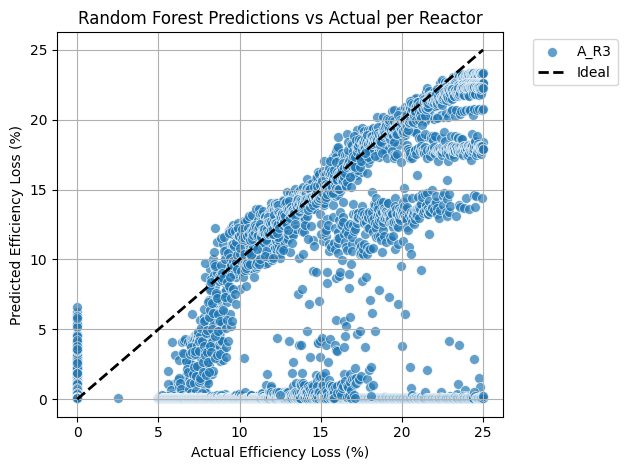

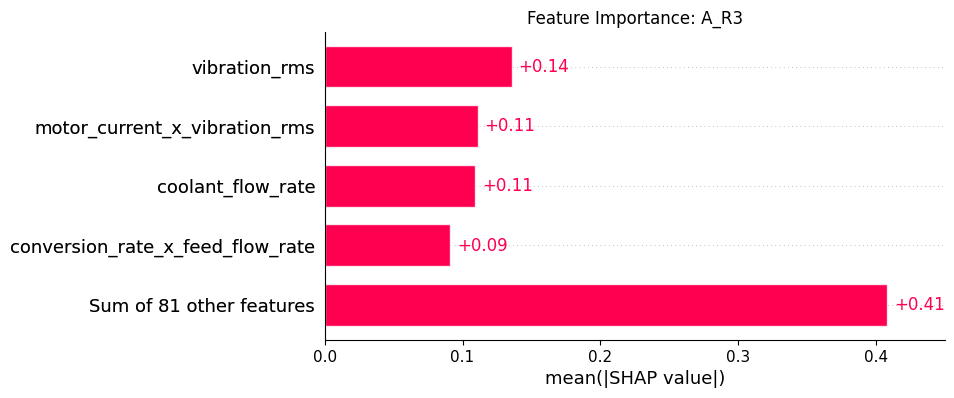

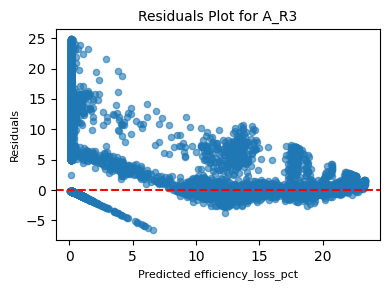

  test_reactor  train_mae  train_mse  train_r2  test_mae   test_mse   test_r2  \
2         A_R3   0.223353   0.957158  0.893608  0.332937   2.788773  0.691361   
1         A_R2   0.274184   1.498072  0.858109  0.321215   2.008123  0.657149   
0         A_R1   0.241149   1.106987  0.851528  3.475932  27.171019 -1.252593   

     oob_r2  
2  0.892351  
1  0.856977  
0  0.849955  


In [31]:
# Create Empty List for Results
results = []

# Loop Through Each Reactor
for test_reactor in reactor_names_A:

    # Split Train/Test by Reactor
    train_df = df_combined[df_combined['reactor_id'] != test_reactor].copy()
    test_df  = df_combined[df_combined['reactor_id'] == test_reactor].copy()

    # Remove reactor_id Column
    train_df = train_df.drop(columns=['reactor_id'])
    test_df  = test_df.drop(columns=['reactor_id'])

    # Identify Target-Related columns to Remove
    target_related_cols = [col for col in train_df.columns if 'efficiency_loss_pct' in col]

    # Put Into Test and Train Variables
    X_train = train_df.drop(columns = target_related_cols)
    y_train = train_df['efficiency_loss_pct']

    X_test = test_df.drop(columns = target_related_cols)
    y_test = test_df['efficiency_loss_pct']
        
    # Set Up Random Forest
    reg = RandomForestRegressor(
        max_depth = 5,
        min_samples_leaf = 5,
        min_samples_split = 15,
        n_estimators = 50,
        max_features = 0.3,
        max_samples = 0.25,  
        n_jobs = -1,
        random_state = seed_1,
        oob_score = True
    )

    # Fit the Model
    reg.fit(X_train, y_train)

    # Save
    model_filename = f"../model/model_base_{test_reactor}.joblib"
    joblib.dump(reg, model_filename)

    # Get Predictions
    y_train_pred = reg.predict(X_train)
    y_test_pred  = reg.predict(X_test)

    # Review Metrics
    results.append({
        'test_reactor': test_reactor,
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'oob_r2': reg.oob_score_
    })

    # Get Test Residuals
    residuals = y_test - y_test_pred

    # Prediction Scatter Plot
    sns.scatterplot(x=y_test, y=y_test_pred, label=test_reactor, s=50, alpha=0.7)

    # Plot the y=x line
    plt.plot([df_combined['efficiency_loss_pct'].min(), df_combined['efficiency_loss_pct'].max()],
            [df_combined['efficiency_loss_pct'].min(), df_combined['efficiency_loss_pct'].max()],
            'k--', lw=2, label='Ideal')

    # Set Up Plot
    plt.xlabel('Actual Efficiency Loss (%)')
    plt.ylabel('Predicted Efficiency Loss (%)')
    plt.title('Random Forest Predictions vs Actual per Reactor')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Get SHAP
    explainer = shap.TreeExplainer(reg)
    shap_ex = explainer(X_test, check_additivity=False)

    # Plot Feature Importance
    plt.title(f"Feature Importance: {test_reactor}")
    shap.plots.bar(shap_ex, max_display = 5)
    plt.show()
    
    # Residuals Plot
    plt.figure(figsize=(4,3))
    plt.scatter(y_test_pred, residuals, s=20, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted efficiency_loss_pct", fontsize=8)
    plt.ylabel("Residuals", fontsize=8)
    plt.title(f"Residuals Plot for {test_reactor}", fontsize=10)
    plt.tight_layout()
    plt.show()

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display R2 Results
results_df = results_df.sort_values('test_r2', ascending=False)
print(results_df)

#### <b>Note: All models score highly when predicting unseen sensor data, as shown by OOB performance. However, each model appears to learn reactor-specific rules that do not transfer easily across units. Feature importance suggests that `A_R1` is highly susceptible to changes in `reactor_temp`, while other reactors show signs of higher complexity and potential overfitting.</b> 

#### <b>Based on R2 values, `A_R1` is an outlier: its predictive performance drops more when applied to other reactors. `A_R3` performs best, capturing the physical trend and transferring relatively better to other units. `A_R2` is intermediate, with moderate transferability. Residual patterns indicate that the model does not fully capture reactor-specific behavior and may be missing a linear component in the system.</b>

#### <b>MSE and MAE show a similar pattern for `A_R1`: MAE increases from train to test, and MSE rises substantially, indicating larger outlier errors in test predictions. For `A_R2` and `A_R3`, this increase is less severe, suggesting better capture of feature-target relationships.</b>

#### <b>Independent models for each reactor will be considered next.</b>

### <b>Model (Separate)</b>

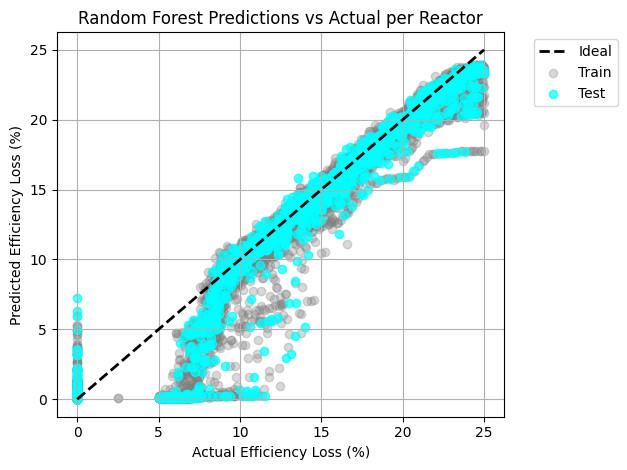

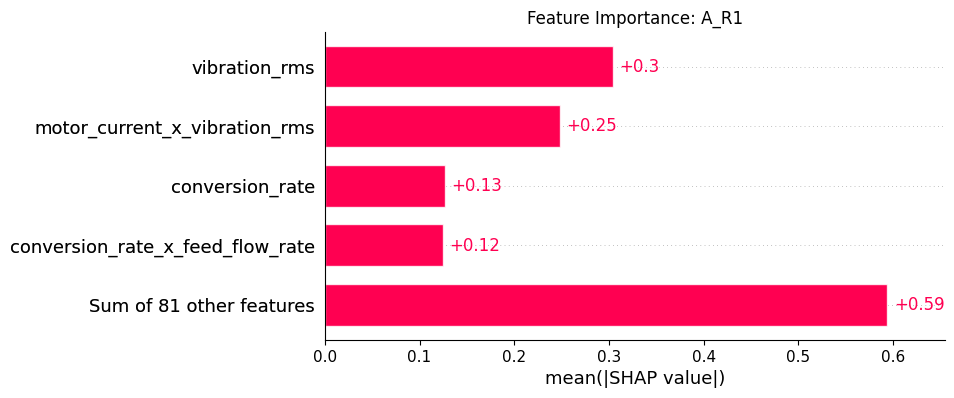

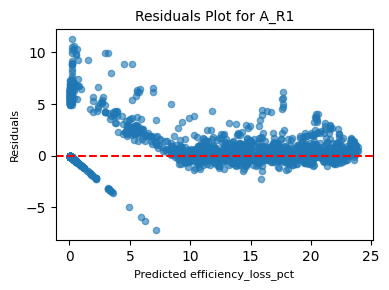

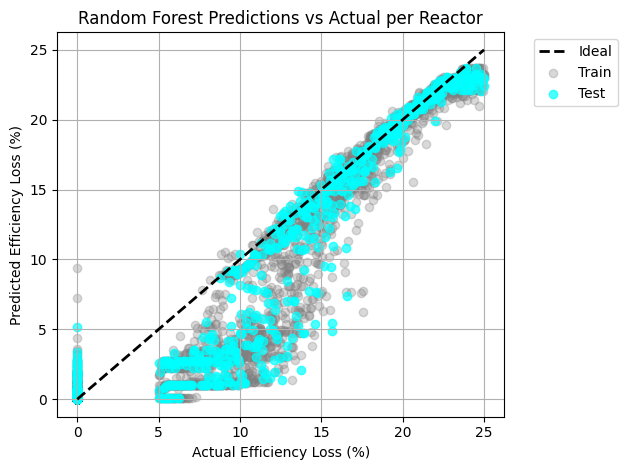

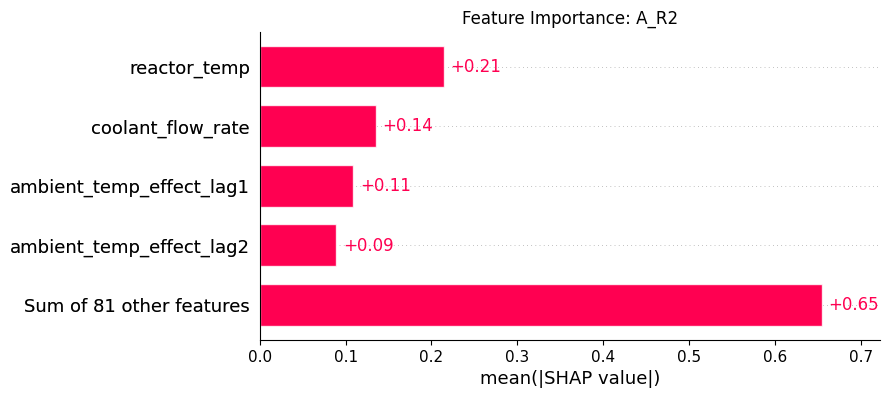

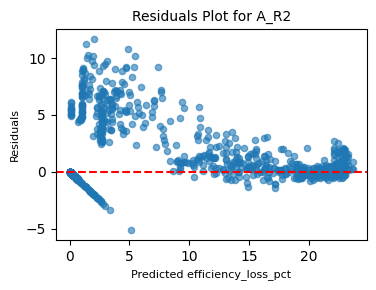

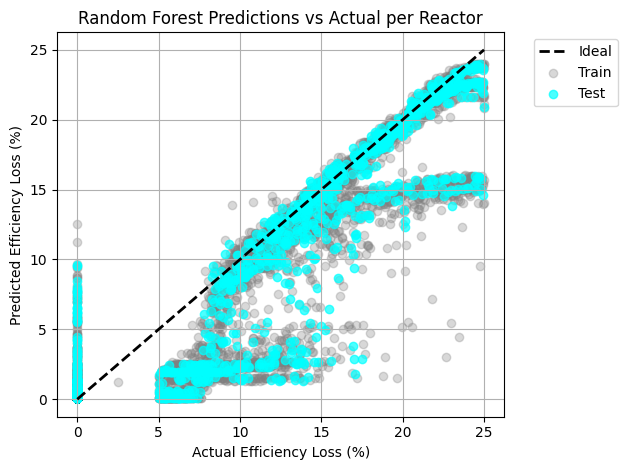

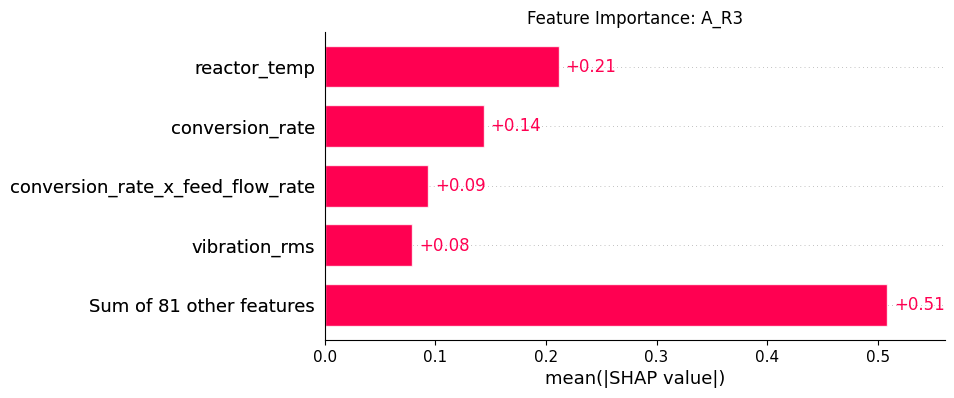

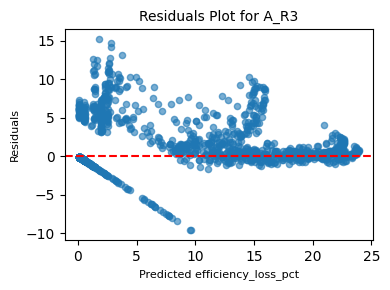

  reactor  train_r2   test_r2    oob_r2  test_mae
0    A_R1  0.971086  0.970646  0.970307  0.145991
1    A_R2  0.940208  0.936865  0.938914  0.121296
2    A_R3  0.920864  0.923703  0.918651  0.204335


In [32]:
# Create Empty List and Dictionary for Results
results_sep = []
models = {}

# Loop Through Each Reactor
for reactor in reactor_names_A:
    
    # Get Based on Reactor ID
    reactor_df = df_combined[df_combined['reactor_id'] == reactor].copy()
    
    # Remove Target Columns
    target_related_cols = [col for col in train_df.columns if 'efficiency_loss_pct' in col]
    
    X = reactor_df.drop(columns=['reactor_id'] + target_related_cols)
    y = reactor_df['efficiency_loss_pct']

    # 80/20 Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.20, random_state = seed_1
    )

    # Set Up Random Forest
    reg = RandomForestRegressor(
        max_depth = 5,
        min_samples_leaf = 5,
        min_samples_split = 15,
        n_estimators = 50,
        max_features = 0.3,
        max_samples = 0.25,  
        n_jobs = -1,
        random_state = seed_1,
        oob_score = True
    )

    # Evaluate Model on Training Data
    reg.fit(X_train, y_train)
    models[reactor] = reg

    # Save model
    joblib.dump(reg, f"../model/model_sep_{reactor}.joblib")

    # Get Predictions for Test and Train
    y_train_pred = reg.predict(X_train)
    y_test_pred  = reg.predict(X_test)

    # Append Results to Output
    results_sep.append({
        'reactor': reactor,
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'oob_r2': reg.oob_score_,
        'test_mae': mean_absolute_error(y_test, y_test_pred)
    })

    # Get Residuals
    residuals = y_test - y_test_pred

    # Plot the y=x line
    plt.plot([df_combined['efficiency_loss_pct'].min(), df_combined['efficiency_loss_pct'].max()],
            [df_combined['efficiency_loss_pct'].min(), df_combined['efficiency_loss_pct'].max()],
            'k--', lw=2, label='Ideal')
    plt.scatter(y_train, y_train_pred, alpha=0.3, label='Train', color='gray')
    plt.scatter(y_test, y_test_pred, alpha=0.7, label='Test', color='cyan')

    # Set Up Plot
    plt.xlabel('Actual Efficiency Loss (%)')
    plt.ylabel('Predicted Efficiency Loss (%)')
    plt.title('Random Forest Predictions vs Actual per Reactor')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Get SHAP
    explainer = shap.TreeExplainer(reg)
    shap_ex = explainer(X_test, check_additivity=False)

    # Plot Feature Importance
    plt.title(f"Feature Importance: {reactor}")
    shap.plots.bar(shap_ex, max_display = 5)
    plt.show()

    # Residuals Plot
    plt.figure(figsize=(4,3))
    plt.scatter(y_test_pred, residuals, s=20, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted efficiency_loss_pct", fontsize=8)
    plt.ylabel("Residuals", fontsize=8)
    plt.title(f"Residuals Plot for {reactor}", fontsize=10)
    plt.tight_layout()
    plt.show()

# Final Results
df_sep = pd.DataFrame(results_sep)
print(df_sep)

#### <b>Note: The training and test R2 values are close, which suggests limited overfitting. OOB scores are high, indicating that the modeling approach works well within the same reactor type. Feature importance suggests that `efficiency_loss_pct` is primarily influenced by chemical imbalance or motor issues for `A_R1`, temperature sensitivity for `A_R2`, and a combination of factors for `A_R3`.</b>

#### <b>Residual plots show better performance at higher target values than at lower ones. This indicates that the model struggles more with predicting small `efficiency_loss_pct` values.</b>

# <b>Conclusion</b>

Initially, a Random Forest model was used to focus on Regime A in a leave-one-reactor-out simulation. With conflicting R2 values and predictions, and with `A_R1` acting as an outlier that is highly susceptible to `reactor_temp`, the model did not generalize well across reactors. 

After shifting to independent reactor models, cross-reactor generalization was no longer required, and the new models captured reactor-specific vulnerabilities more effectively when predicting `efficiency_loss_pct`. This improvement was reflected in R2, MAE, and MSE results. 

A key limitation is the use of 80+ features, many of which dominate feature importance and increase computational cost. Reducing feature count and focusing on the most informative drivers would likely improve both model quality and runtime. 

There is also bias at lower efficiency-loss levels, where the model struggles to reason through small values. Applying a log-linear approach for lower-range targets may help the model capture structure within that noise region.

# <b>Potential Work</b>

- Dimensionality reduction (PCA) to simplify computation and reduce runtime

- Hyperparameter tuning to improve accuracy and efficiency

- Downsampling to reduce noise and improve performance

- Per-unit calibration (standardization), especially for other model families

- Evaluating additional tree-based models beyond `RandomForestRegressor`

- Examining abrupt sensor changes to detect potential machine defects

- Including additional columns, such as setpoints

- Applying physical models

    - Arrhenius equation
    
    - Conservation of energy
    
    - Mass balances
    
    - Ohm's law

- Exploring temperature seasonality

- Additional improvement areas

    - Regime B analysis
    
    - Value anomaly detection

    - Fault classification

    - Time-series forecasting of variables

- Unsupervised learning to discover hidden trends